In [13]:
import mcmr

In [14]:
geom = mcmr.Geometry(
    x_world=64, y_world=64,
    default_material="Fe",
    default_source=0,
    bc_top="reflective",
    bc_bot="reflective",
    bc_left="reflective",
    bc_right="reflective",
)

geom.add_region(8, 8, 56, 56, material="Be")

for i in range(8, 64, 16):
    geom.fill_col(i, i+8, material="Pb", source=0)
    geom.fill_row(i, i+8, material="Pb", source=0)

for i in range(4, 64, 8):
    for j in range(4, 64, 8):
        geom.add_circle(x=i, y=j, r=2.5, material="C", source=1)

In [15]:
world = geom.build()

In [16]:
world.export("mcmr_world.xml")

'mcmr_world.xml'

In [17]:
sim = world.run(N=1000, max_save=10)

              MCMR Simulation Engine               
 Total Particle   : 1000
running...
Progress: [1000/1000] (100%)
 Simulation End in 1.9447 seconds.



In [18]:
sim.export_xml("geom_result.xml")

In [19]:
t = sim.get_tally()
print(t.absorp_by_material)

{'Be': 258, 'C': 258, 'Fe': 423, 'Pb': 61}


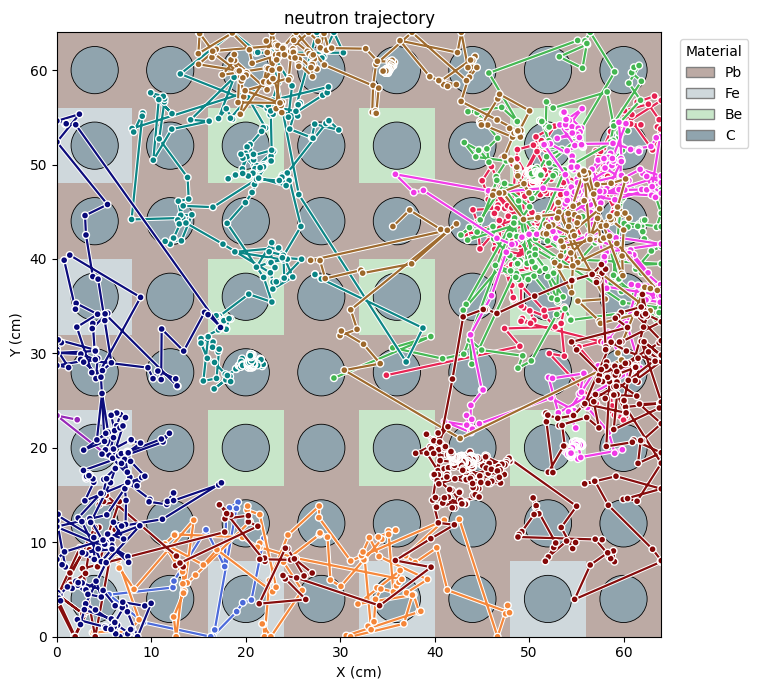

In [20]:
plotter = mcmr.ResultsPlotter("geom_result.xml")
plotter.plot_trajectories(world_xml="mcmr_world.xml")